# **Weathering mediated bedrock erosion: Simulation**

For so-called weathering (supply) limitation, $W \ll 1/4$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx 1+W
    \quad\Leftrightarrow\quad
    u_s \approx  u_0 + \frac{w_0}{k}
\end{equation}

For so-called erosion limitation (unlimited supply), $W \gg 2.5$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx \dfrac{1}{2}+ \sqrt{W}
    \quad\Leftrightarrow\quad
    u_s \approx \dfrac{1}{2}+\sqrt{\frac{w_0 u_0}{k}}
\end{equation}



# Numerical integration

## Preliminaries

In [1]:
from essentials import *

In [2]:
wmbe_model = WeatheringMediatedErosion()
viz = Viz(dpi=120,)

## High $W$

In [3]:
physical_parameters = {
    w_0: np.float64(100),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
ew_highW = ErosionWeathering(physical_parameters, model_parameters,)
ew_highW.model_parameters
ew_highW.solve()
ew_highW.physical_parameters

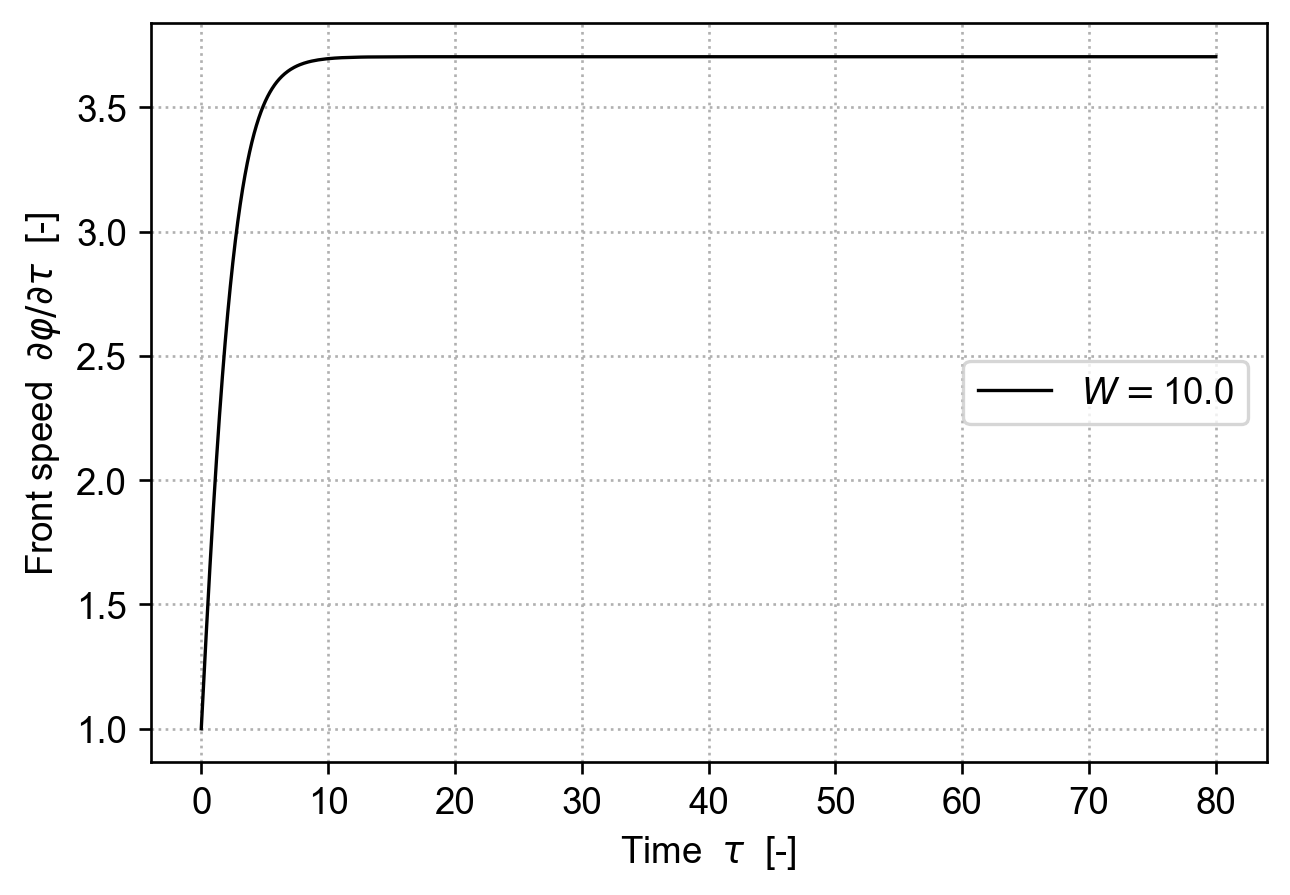

In [4]:
name = "highW_frontspeed_evolution"
viz.frontspeed_evolution(name, ew=ew_highW)

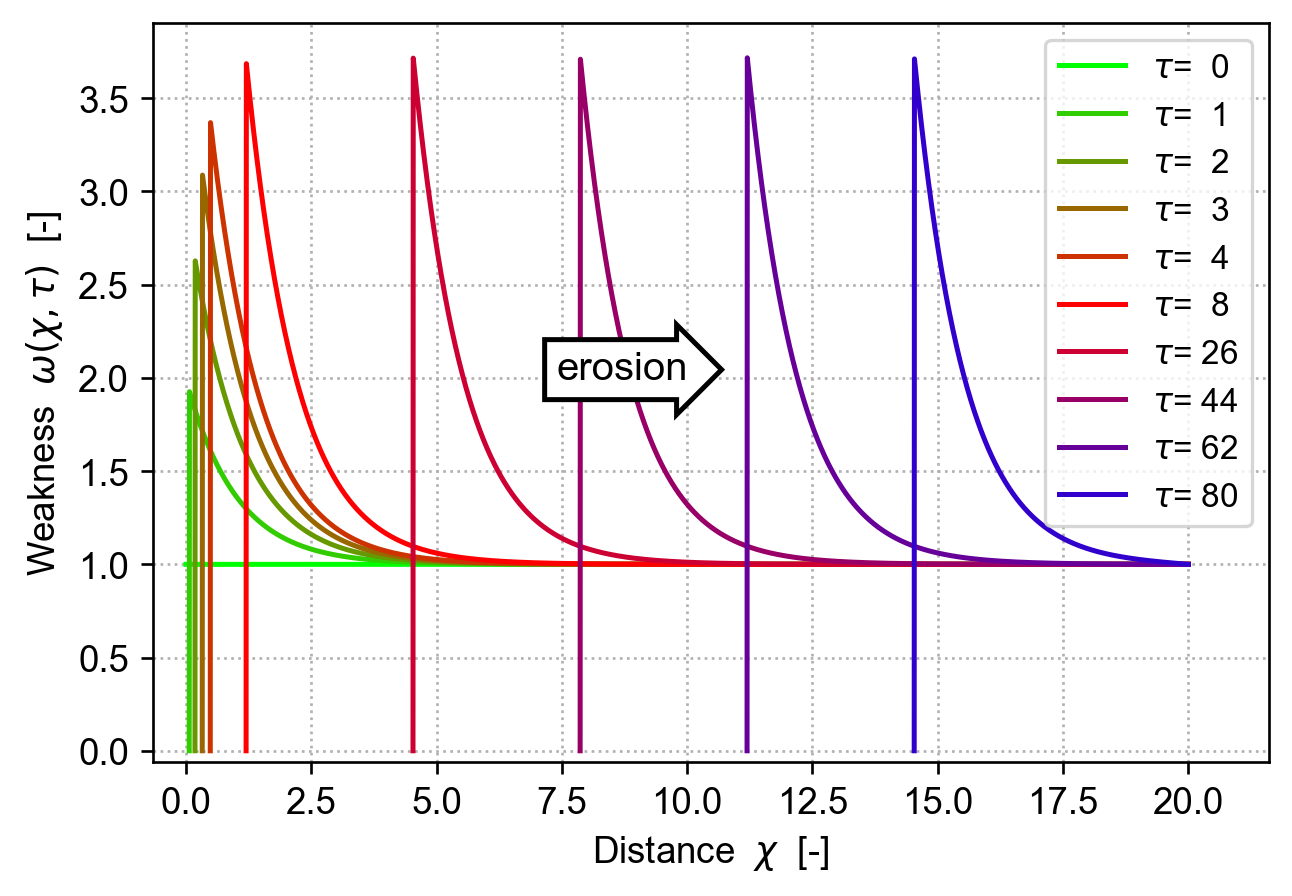

In [5]:
name = "highW_weakness_evolution"
viz.weakness_evolution(name, ew=ew_highW, tc=20, nd=0,)

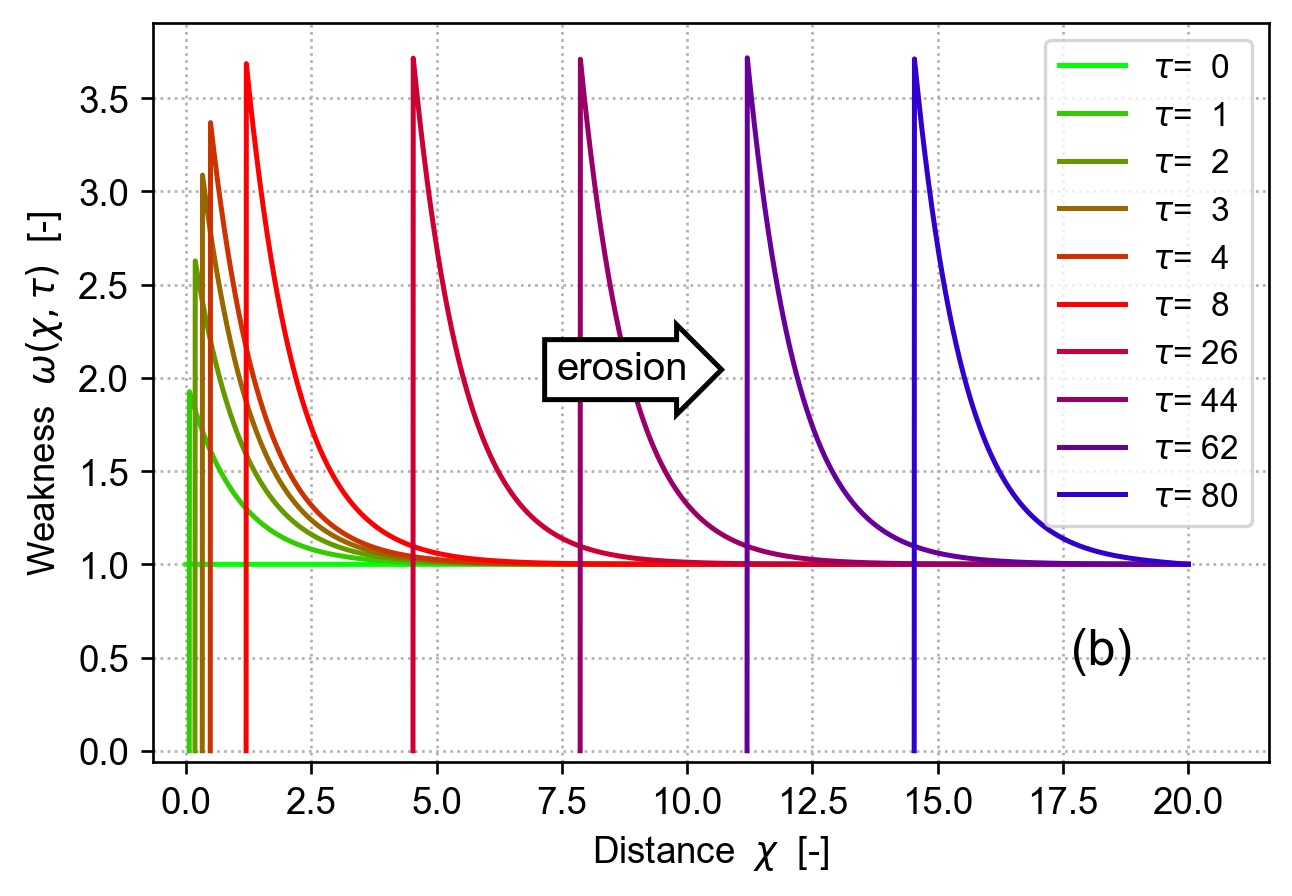

In [6]:
name = "highW_weakness_evolution_subfigb"
viz.weakness_evolution(
    name, ew=ew_highW, tc=20, nd=0, text_label=((0.85,0.15),"(b)",15),
)

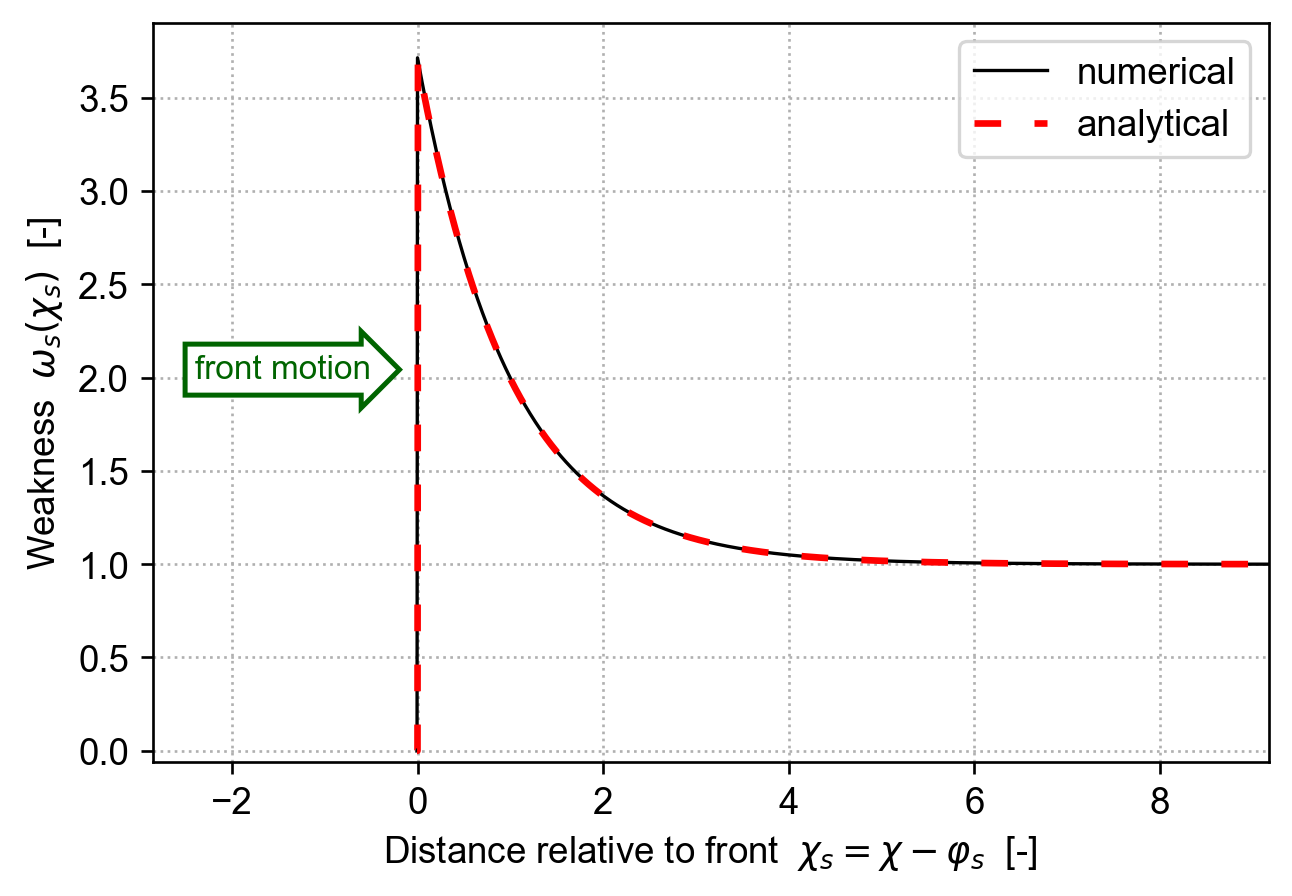

In [7]:
name = "highW_weakness_ss"
viz.weakness_steadystate(name, ew=ew_highW,)

## High transitional $W$

In [8]:
physical_parameters = {
    w_0: np.float64(25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
ew_highTransW = ErosionWeathering(physical_parameters, model_parameters,)
ew_highTransW.model_parameters
ew_highTransW.solve()
ew_highTransW.physical_parameters

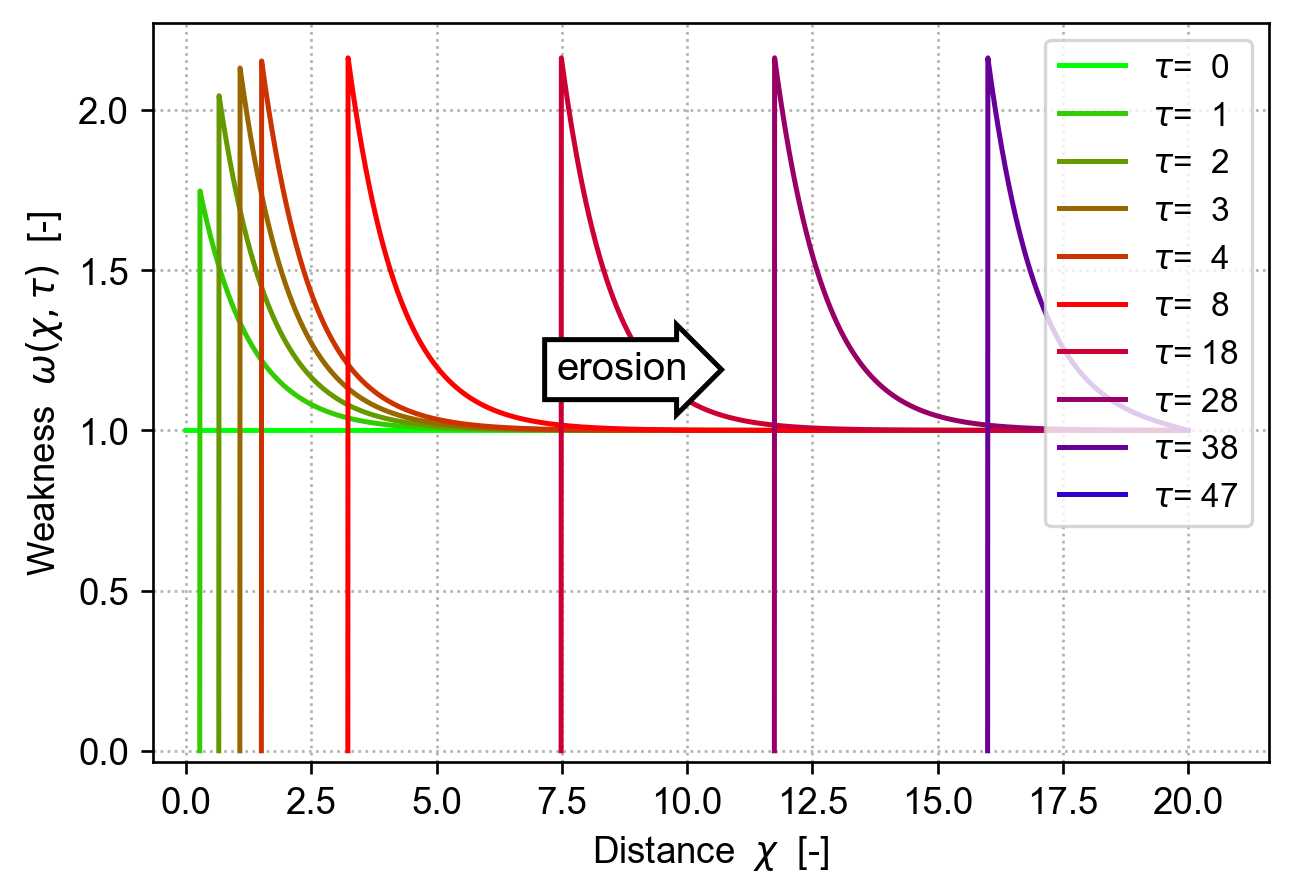

In [9]:
name = "highTransW_weakness_evolution"
viz.weakness_evolution(
    name, ew=ew_highTransW, tc=20, nd=0,
)

## Low-transitional $W$

In [10]:
physical_parameters = {
    w_0: np.float64(2.5),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 30.0,
    tau_domain_size: 10.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.003
}
ew_lowTransW = ErosionWeathering(physical_parameters, model_parameters,)
ew_lowTransW.model_parameters
ew_lowTransW.solve()
ew_lowTransW.physical_parameters

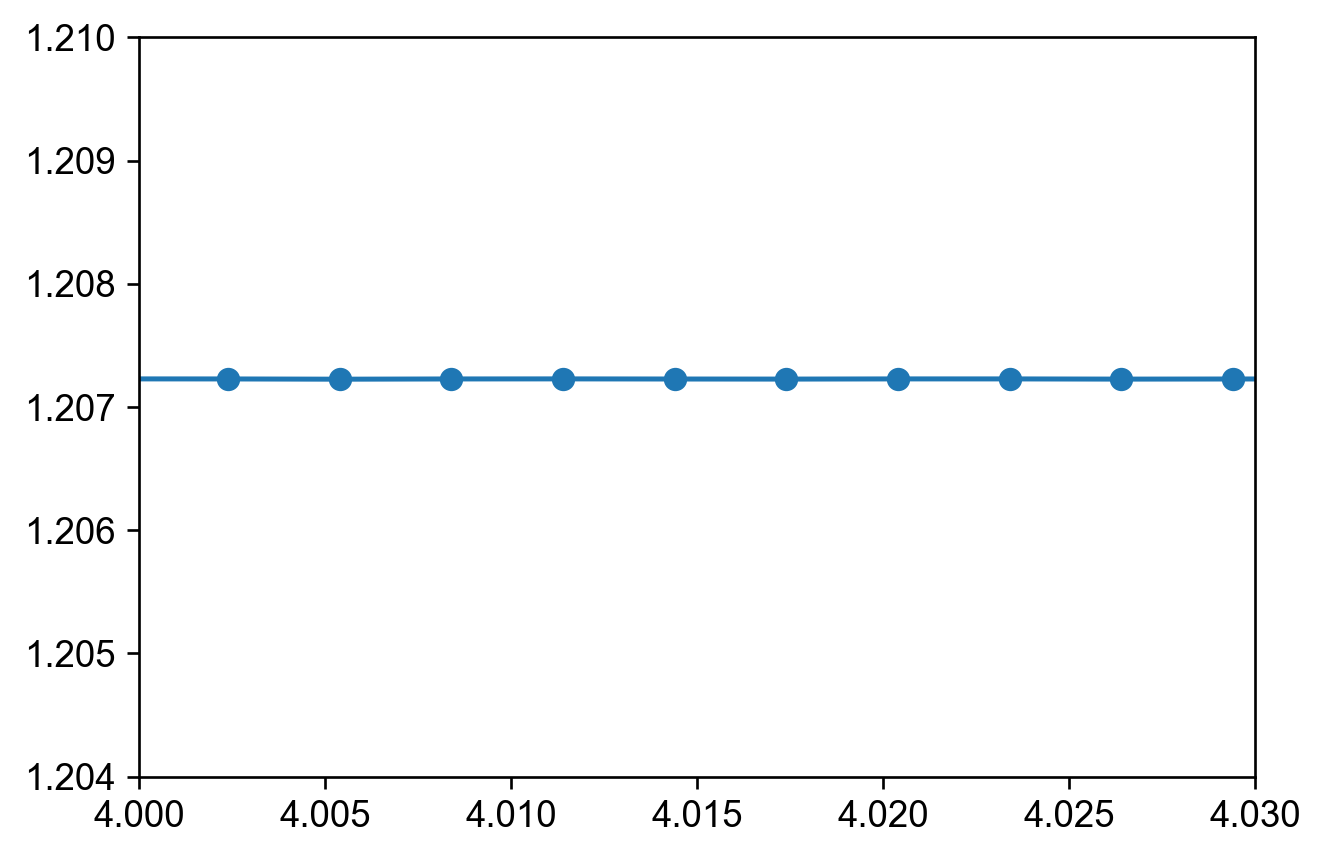

In [11]:
name = "stability_check"
viz.stability_check(
    name, tau=ew_lowTransW.tau_array, nu=ew_lowTransW.nu_array,
)

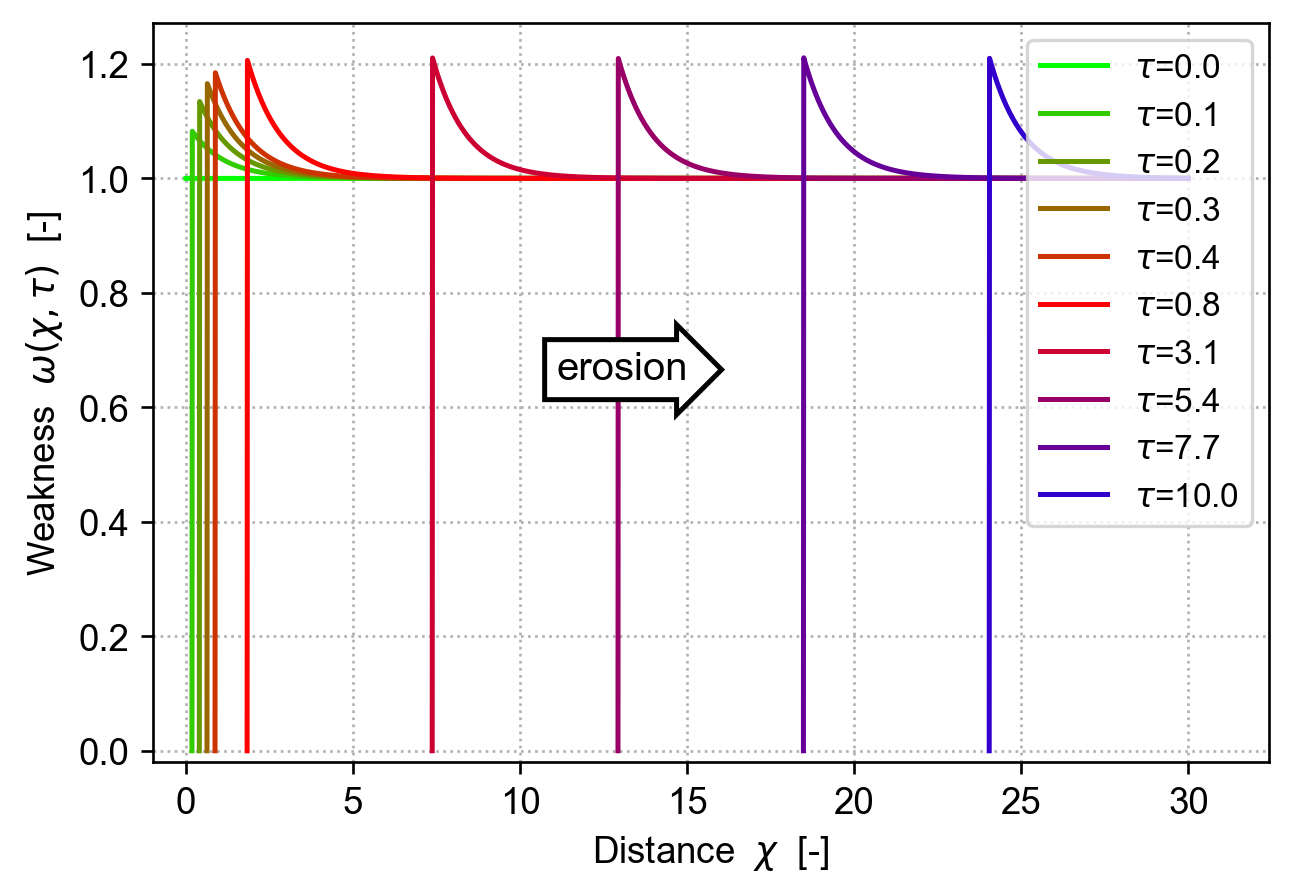

In [12]:
name = "lowTransW_weakness_evolution"
viz.weakness_evolution(
    name, ew=ew_lowTransW, tc=25, nd=1,
)

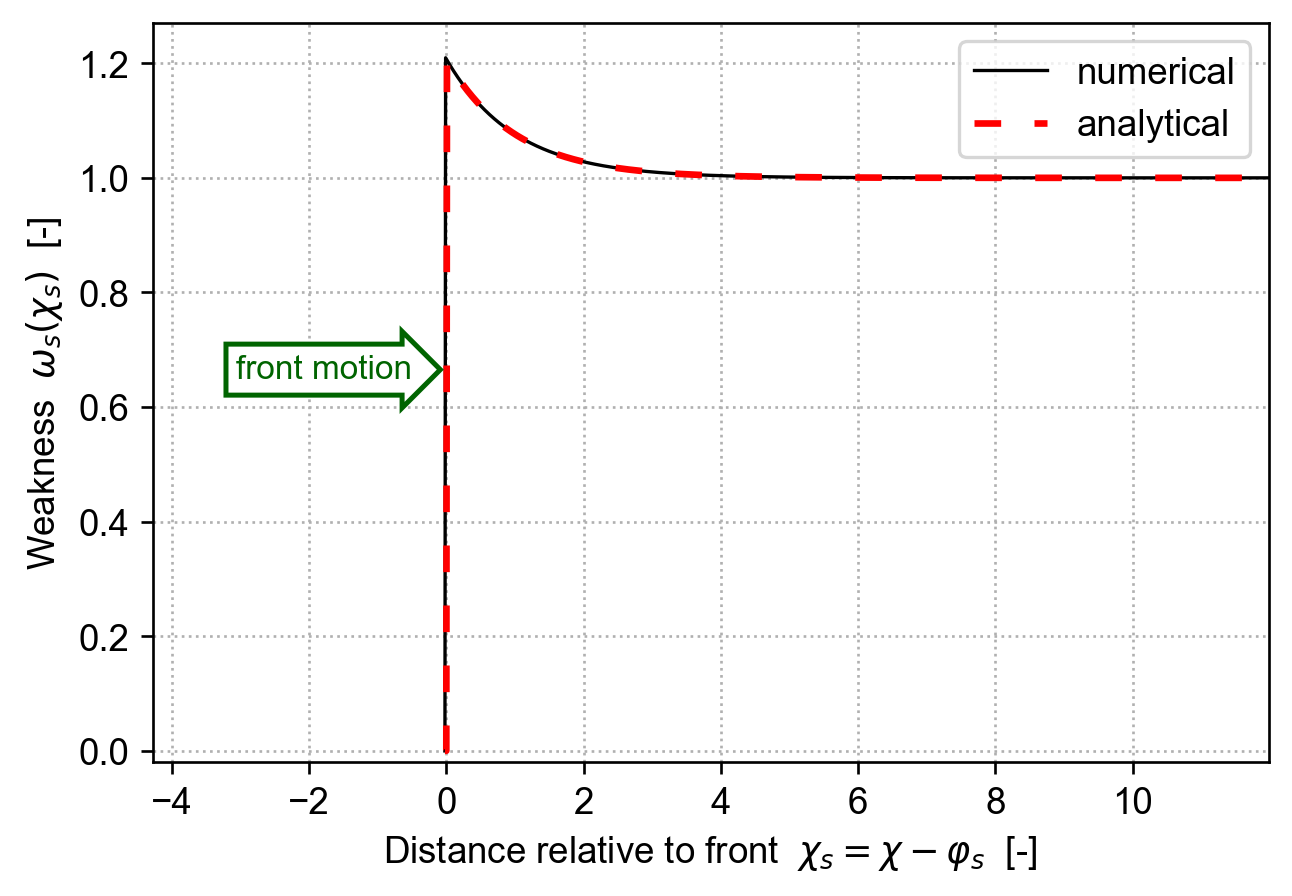

In [13]:
name = "lowTransW_weakness_ss"
viz.weakness_steadystate(name, ew=ew_lowTransW,)

## Low $W$

In [14]:
physical_parameters = {
    w_0: np.float64(0.25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 30.0,
    tau_domain_size: 1.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.0003
}
ew_lowW = ErosionWeathering(physical_parameters, model_parameters,)
ew_lowW.model_parameters
ew_lowW.solve()
ew_lowW.physical_parameters

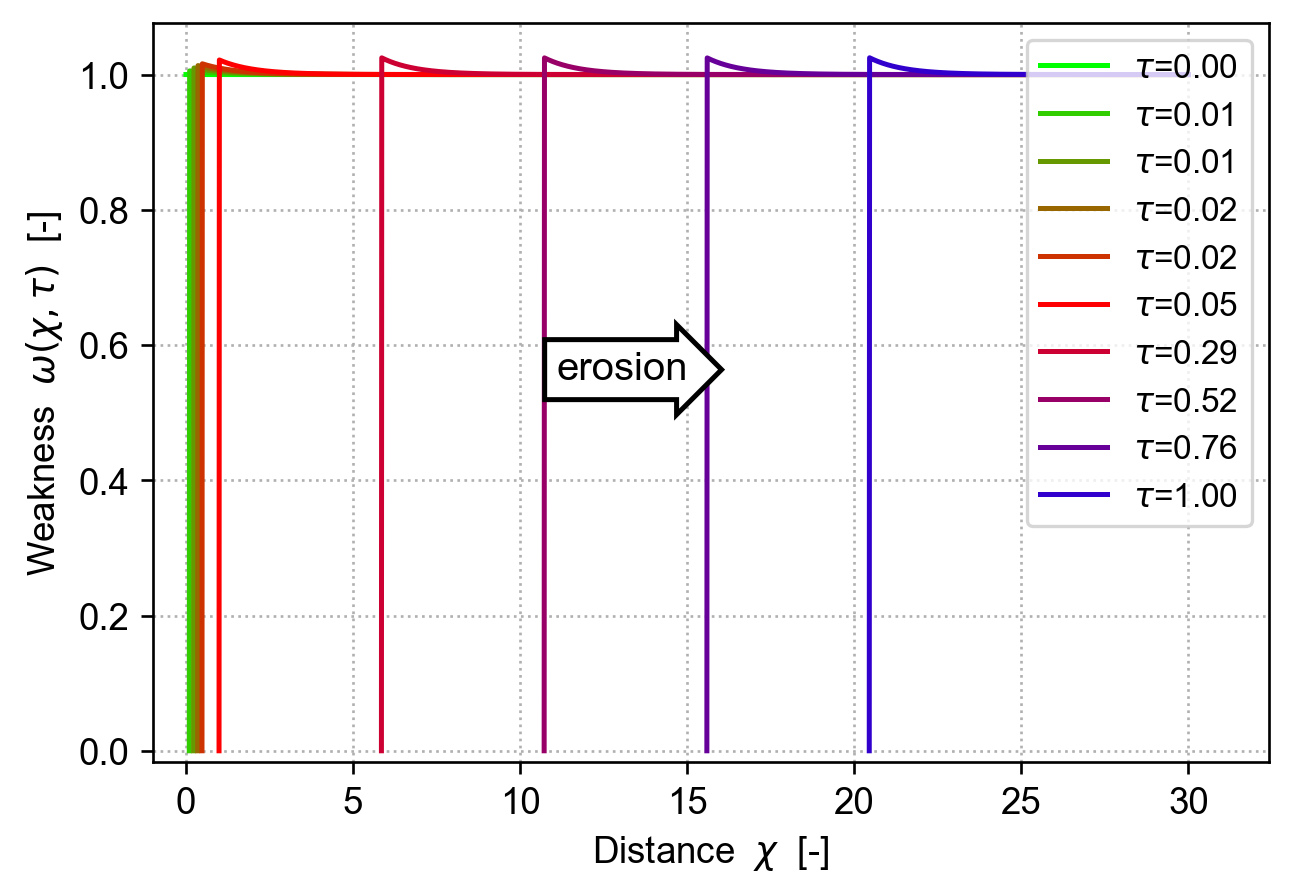

In [15]:
name = "lowW_weakness_evolution"
viz.weakness_evolution(name, ew=ew_lowW,)

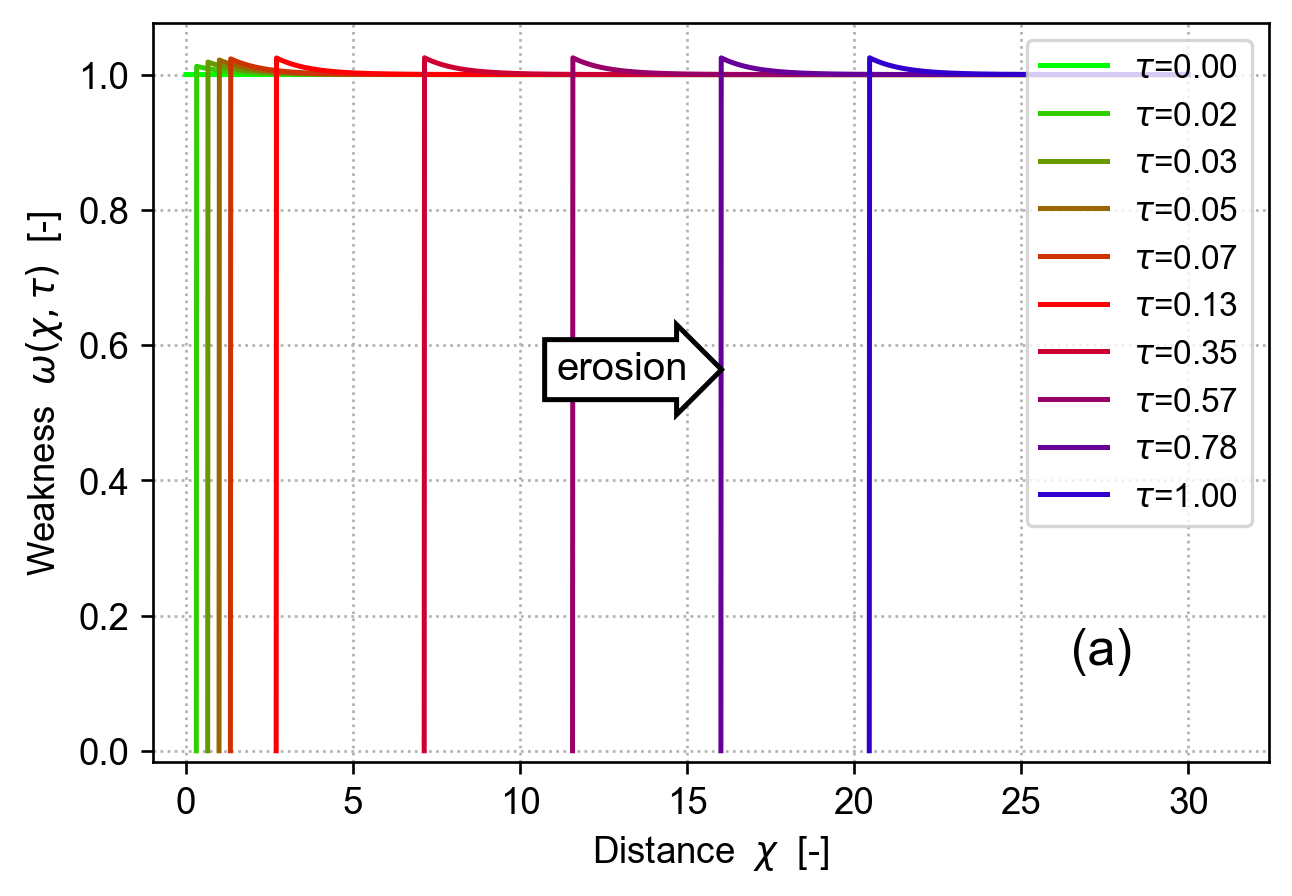

In [16]:
name = "lowW_weakness_evolution_subfiga"
viz.weakness_evolution(
    name, ew=ew_lowW, tc=15, text_label=((0.85,0.15),"(a)",15),
)

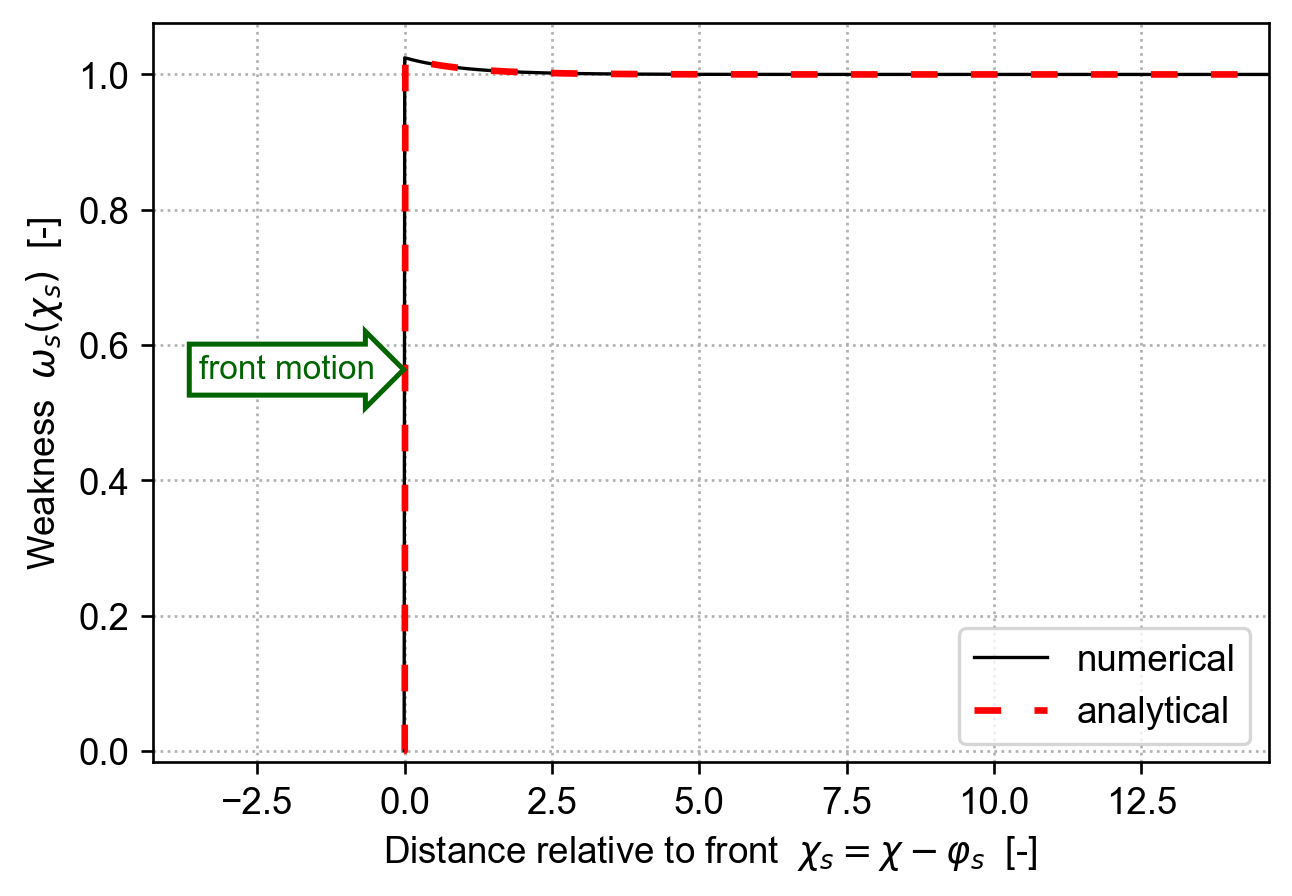

In [17]:
name = "lowW_weakness_ss"
viz.weakness_steadystate(name, ew=ew_lowW,)

## Comparison

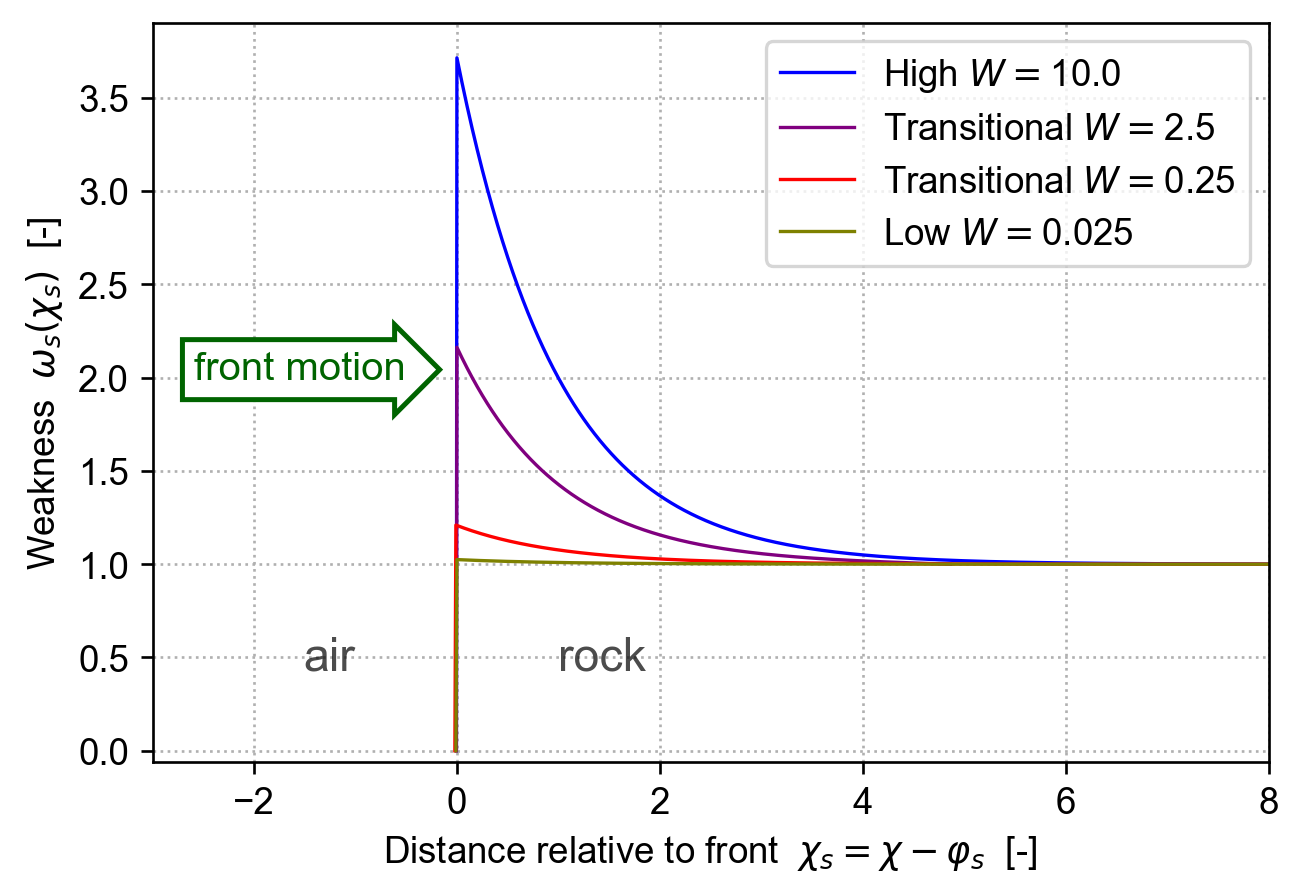

In [18]:
name = "weakness_setW_ss"
ews = (
    (ew_highW, 
        "High $W=$"+str(ew_highW.physical_parameters[W])),
    (ew_highTransW,
        "Transitional $W=$"+str(ew_highTransW.physical_parameters[W])),
    (ew_lowTransW,
        "Transitional $W=$"+str(ew_lowTransW.physical_parameters[W])),
    (ew_lowW,
        "Low $W=$"+str(ew_lowW.physical_parameters[W]))
)
viz.weakness_steadystate_setW(name, ews=ews,)

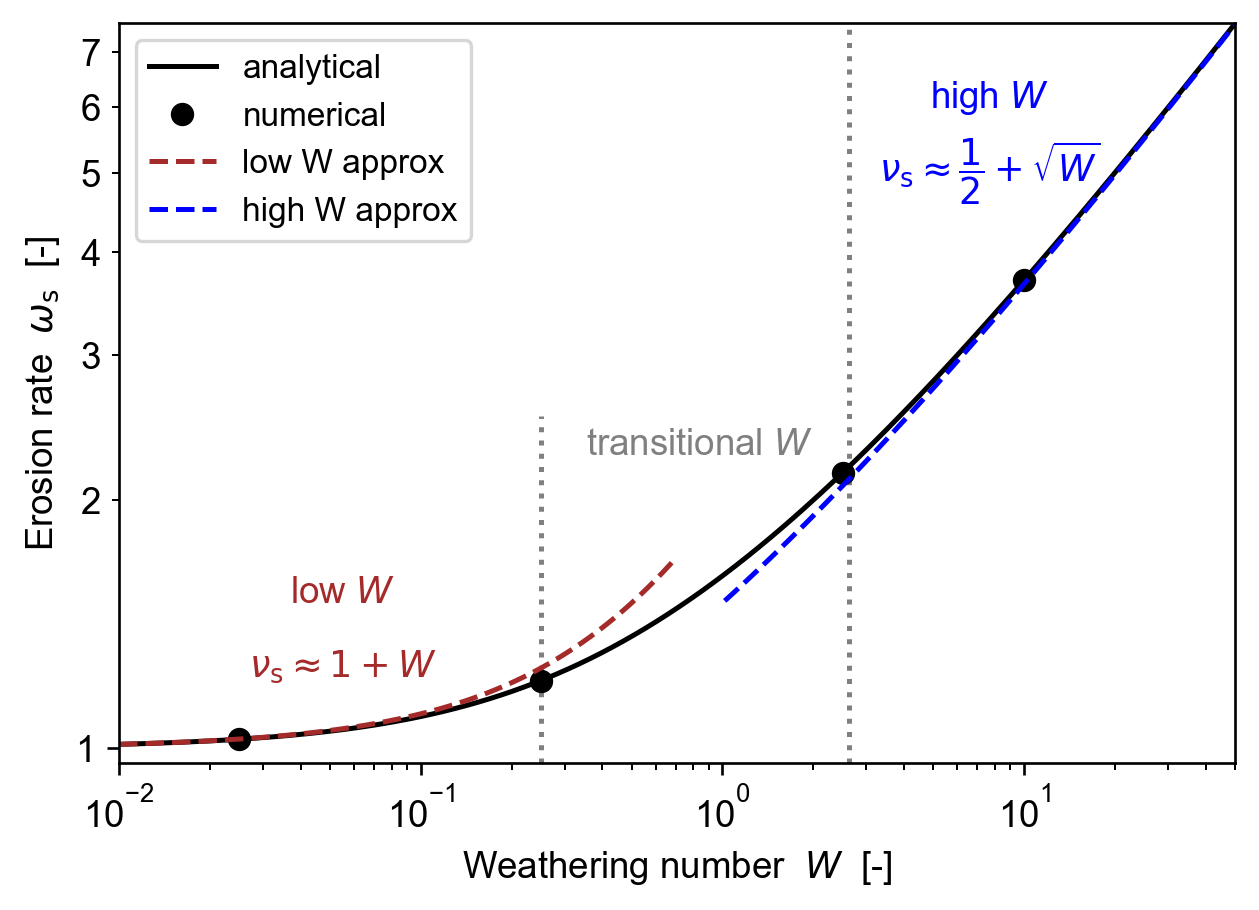

In [19]:
name = "weakness_steadystate"
ews = [ew_lowW, ew_lowTransW, ew_highTransW, ew_highW]
viz.weakness_steadystate_W(name, em=wmbe_model, ews=ews, do_loglog=True,)

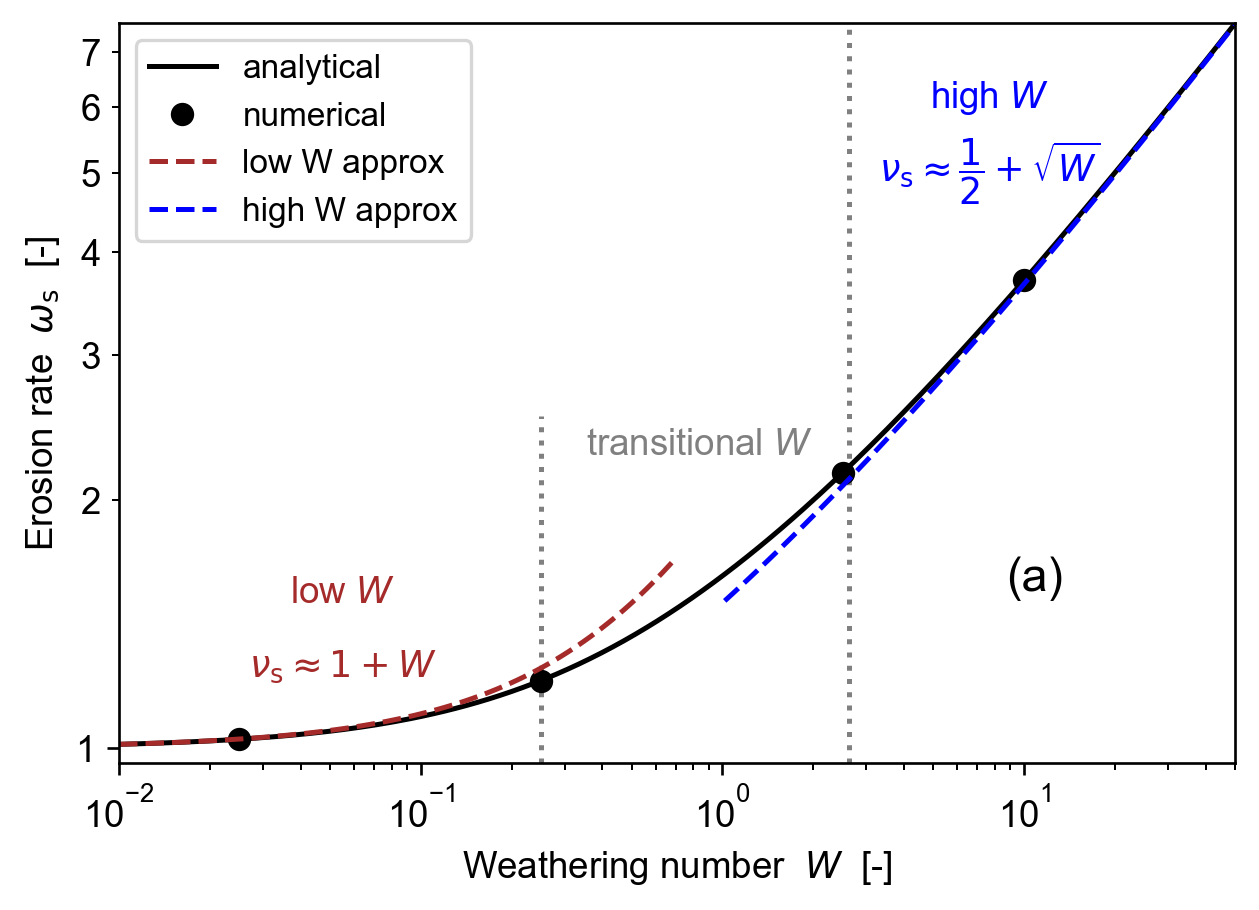

In [20]:
name = "weakness_steadystate_subfiga"
ews = [ew_lowW, ew_lowTransW, ew_highTransW, ew_highW]
viz.weakness_steadystate_W(
    name, em=wmbe_model, ews=ews, do_loglog=True, text_label="(a)",
)

In [21]:
nus_eqn = sy.Eq( nu_s, (1+sy.sqrt(1+4*W))/2 )
nus_lowW_eqn = sy.Eq( nu_s, 1+W )
nus_highW_eqn = sy.Eq( nu_s, ((sy.Rational(1,2)+sy.sqrt(W))) )
nus_lowW_eqn, nus_eqn, nus_highW_eqn
nus_lowW_error = (nus_lowW_eqn.rhs/nus_eqn.rhs)\
                    .subs({W:sy.Rational(1,4)}).simplify()

In [22]:
# sy.simplify( sy.Eq(nus_eqn.rhs,nus_highW_eqn.rhs*nus_lowW_error) )
# nus_highW_lim=sy.solve(_,W)[0]
# nus_highW_lim
# sy.N(nus_highW_lim)

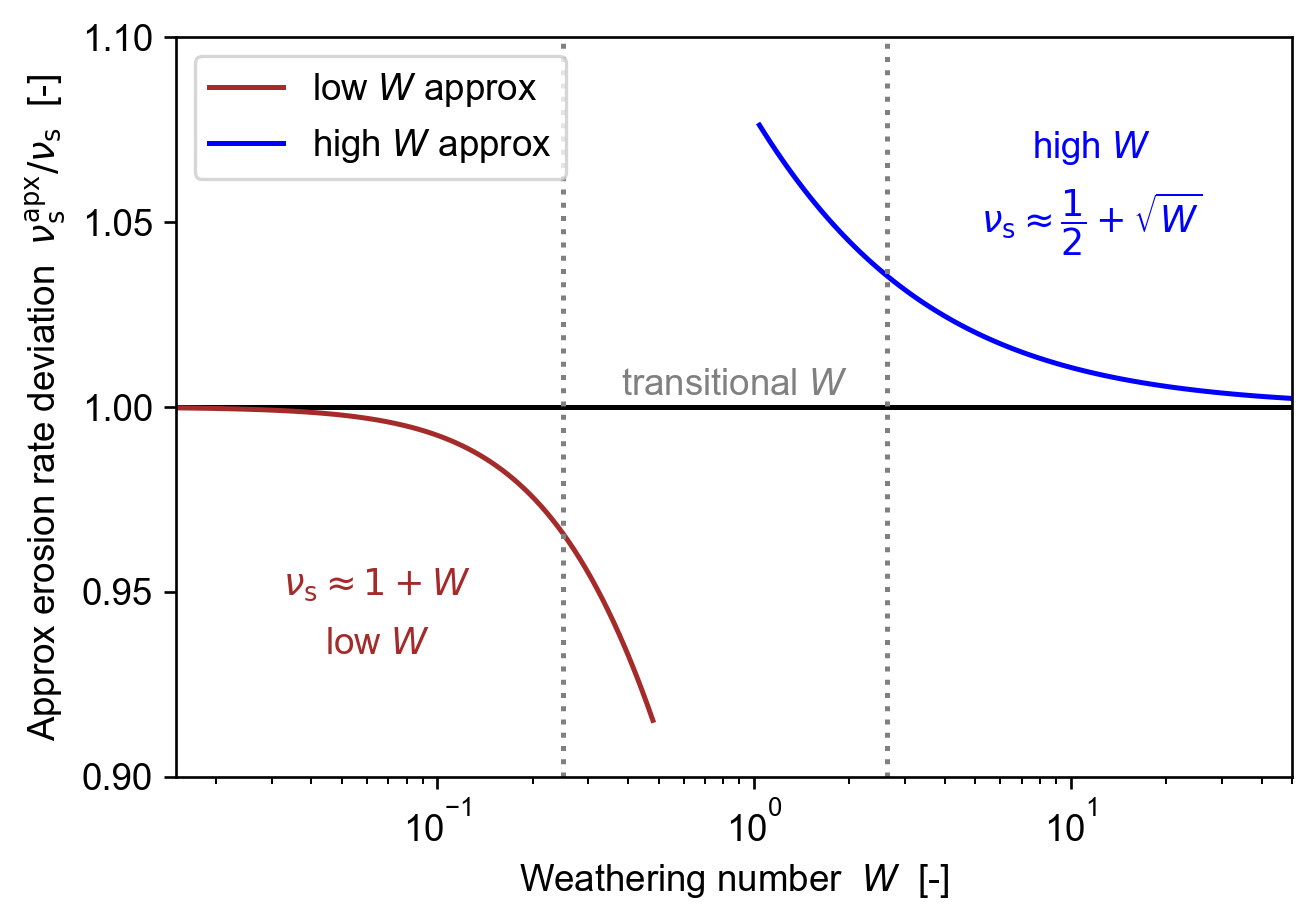

In [23]:
name = "weakness_steadystate_approx_devn"
viz.weakness_steadystate_W_transition(name, em=wmbe_model,)

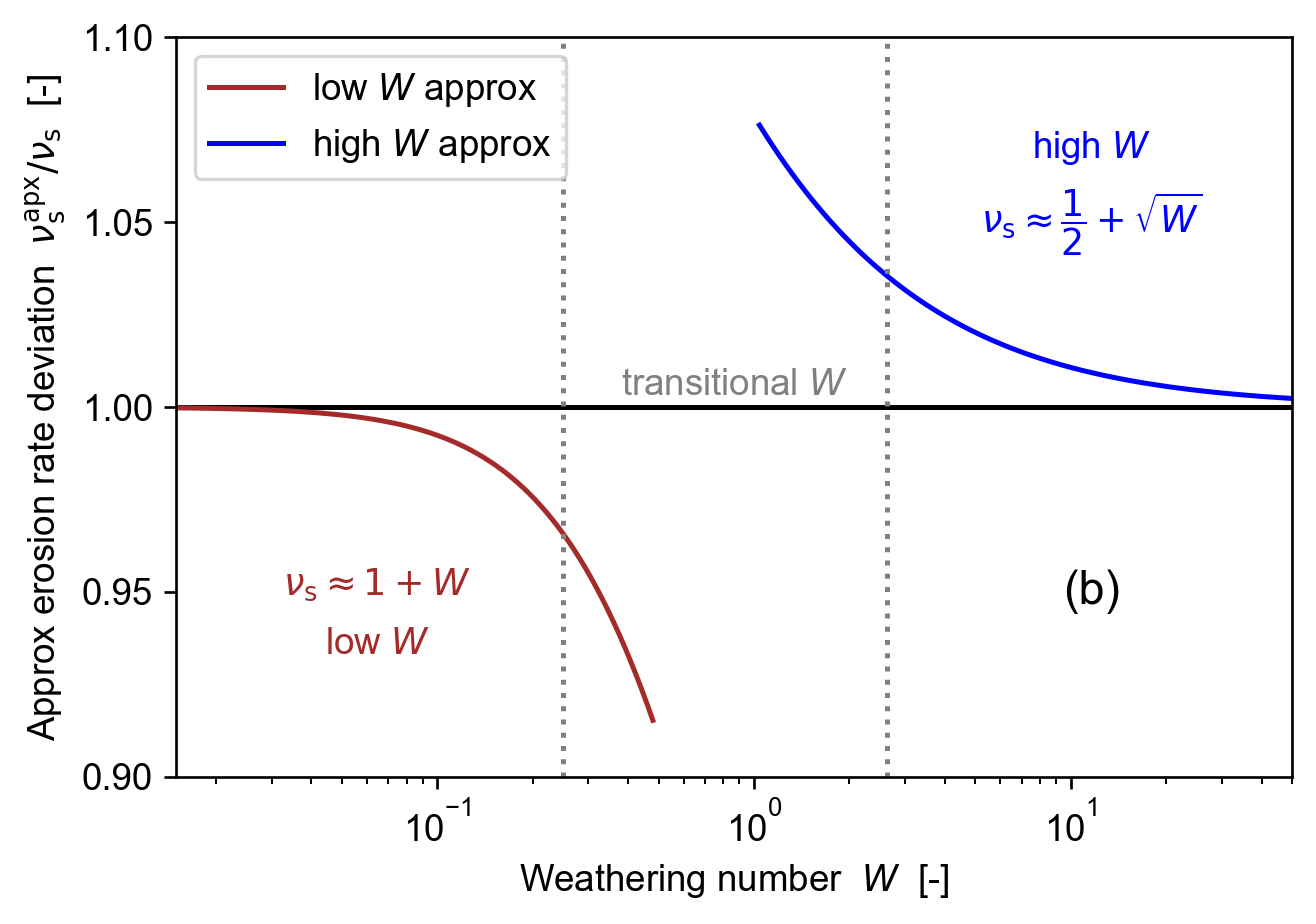

In [24]:
name = "weakness_steadystate_approx_devn_subfigb"
viz.weakness_steadystate_W_transition(
    name, em=wmbe_model, text_label="(b)",
)

# Export

In [25]:
plots_dir: str = create_directories((os.path.curdir,), "plots")
print(tuple(viz.fdict.keys()))
export_plots(
    viz.fdict,
    plots_dir,
    "pdf",
    suffix="",
    dpi=150,
)

('highW_frontspeed_evolution', 'highW_weakness_evolution', 'highW_weakness_evolution_subfigb', 'highW_weakness_ss', 'highTransW_weakness_evolution', 'stability_check', 'lowTransW_weakness_evolution', 'lowTransW_weakness_ss', 'lowW_weakness_evolution', 'lowW_weakness_evolution_subfiga', 'lowW_weakness_ss', 'weakness_setW_ss', 'weakness_steadystate', 'weakness_steadystate_subfiga', 'weakness_steadystate_approx_devn', 'weakness_steadystate_approx_devn_subfigb')


'././plots'

In [26]:
for choice in ("weakness_steadystate", "highW_weakness_evolution"):
    export_plot(
        choice,
        viz.fdict.get(choice),
        plots_dir,
        "png",
        suffix="",
        dpi=150,
    )